This project uses official UK automotive datasets to understand and model manufacturer performance in the 2024–2025 car market. I combine the SMMT 2025 new‑car registration snapshot (by marque) with the DfT df_VEH0160_UK file, which reports vehicles registered for the first time by body type, make, generic model and model each quarter. The notebook starts by cleaning and reshaping these sources into analysis‑ready tables, then applies exploratory data analysis, feature engineering and machine‑learning models to classify high‑ vs low‑sales manufacturers and to detect strong growth quarters for each make.

https://www.gov.uk/government/statistical-data-sets/vehicle-licensing-statistics-data-files

All code, intermediate datasets and figures are stored in my GitHub repository “SMMT‑2025‑UK‑Car‑Sales‑Analysis”:
https://github.com/SunkeAnandasai3784/SMMT-2025-UK-Car-Sales-Analysis.
​

The aim of the project is to build transparent, data‑driven models that (1) classify manufacturers into high and low performers based on SMMT registration volumes and market shares, and (2) predict whether a manufacturer experiences strong year‑on‑year growth in new registrations using time‑series features from df_VEH0160_UK. The main outcomes are: a reproducible preprocessing and feature‑engineering pipeline, realistic Random Forest classifiers with tuned hyper‑parameters (validation ROC‑AUC around 0.79 and test ROC‑AUC around 0.78), and visual diagnostics such as heat maps, learning curves and ROC curves that help interpret both the data and model behaviour.

DfT VEH0160 – loading and reshaping to a panel

In [25]:
      # =====================================================================
# VEH0160
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, log_loss, roc_curve, auc
)to7'/

sns.set(style="whitegrid")

In [26]:
# 1) Harder target: strong positive YoY growth (>10%)
growth_rate = panel_clean["YoY_Growth"] / (np.abs(panel_clean["Registered_lag4"]) + 1e-6)
panel_clean["Target"] = (growth_rate > 0.10).astype(int)

print("New Target counts:", panel_clean["Target"].value_counts().to_dict())
print("New Target share (class 1):", panel_clean["Target"].mean())


New Target counts: {0: 2842, 1: 1369}
New Target share (class 1): 0.3251009261458086


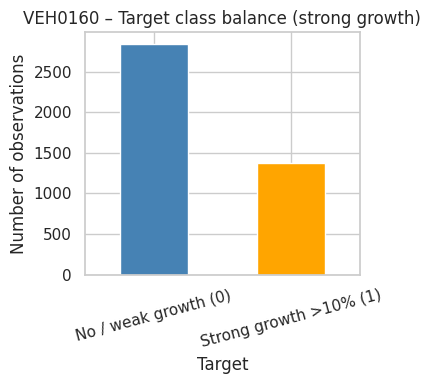

In [27]:
# 2) EDA – class balance
plt.figure(figsize=(4, 4))
panel_clean["Target"].value_counts().sort_index().plot(
    kind="bar", color=["steelblue", "orange"]
)
plt.xticks([0, 1], ["No / weak growth (0)", "Strong growth >10% (1)"], rotation=15)
plt.ylabel("Number of observations")
plt.title("VEH0160 – Target class balance (strong growth)")
plt.tight_layout()
plt.show()

In [28]:

# 3) Feature set: only lags + MA3 (drop YoY_Growth)
feature_cols = [
    "Registered_lag1",
    "Registered_lag2",
    "Registered_lag4",
    "MA3"
]

X = panel_clean[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = panel_clean["Target"]

print("X shape:", X.shape, " y shape:", y.shape)

X shape: (4211, 4)  y shape: (4211,)


In [41]:
feature_cols = [
    "Registered_lag1",
    "Registered_lag2",
    "Registered_lag4",
    "MA3"
]

X = panel_clean[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = panel_clean["Target"]


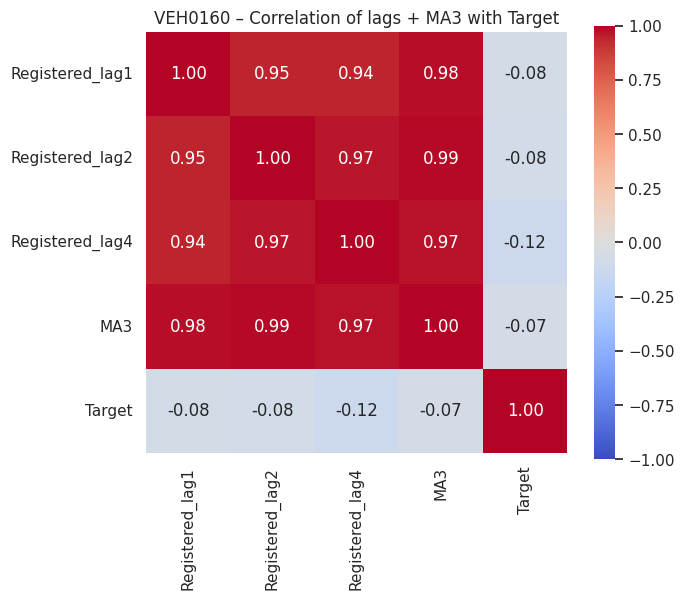

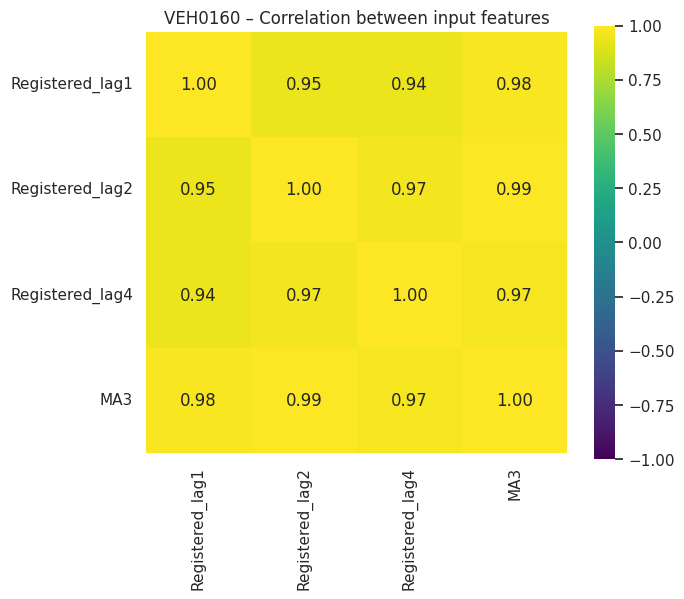

In [29]:
# 4) Heatmaps
heat_df = panel_clean[feature_cols + ["Target"]].copy()
corr_all = heat_df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_all, annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1, square=True
)
plt.title("VEH0160 – Correlation of lags + MA3 with Target")
plt.tight_layout()
plt.show()

corr_inputs = panel_clean[feature_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_inputs, annot=True, fmt=".2f",
    cmap="viridis", vmin=-1, vmax=1, square=True
)
plt.title("VEH0160 – Correlation between input features")
plt.tight_layout()
plt.show()

In [30]:
# 5) Train / validation / test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Train size:", X_train.shape[0])
print("Val size  :", X_val.shape[0])
print("Test size :", X_test.shape[0])

Train size: 2368
Val size  : 790
Test size : 1053


In [32]:


# 6) Baseline RF (small, regularised)
rf_base = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

rf_base.fit(X_train, y_train)

y_train_pred = rf_base.predict(X_train)
y_train_proba = rf_base.predict_proba(X_train)[:, 1]

y_val_pred = rf_base.predict(X_val)
y_val_proba = rf_base.predict_proba(X_val)[:, 1]

print("=== Baseline RF – Train ===")
print(classification_report(y_train, y_train_pred, digits=3))
print("ROC-AUC (train):", roc_auc_score(y_train, y_train_proba))
print("Log loss (train):", log_loss(y_train, y_train_proba))

print("\n=== Baseline RF – Validation ===")
print(classification_report(y_val, y_val_pred, digits=3))
print("ROC-AUC (val):", roc_auc_score(y_val, y_val_proba))
print("Log loss (val):", log_loss(y_val, y_val_proba))



=== Baseline RF – Train ===
              precision    recall  f1-score   support

           0      0.923     0.420     0.577      1598
           1      0.435     0.927     0.592       770

    accuracy                          0.585      2368
   macro avg      0.679     0.674     0.585      2368
weighted avg      0.764     0.585     0.582      2368

ROC-AUC (train): 0.8148737057685743
Log loss (train): 0.5900595645113363

=== Baseline RF – Validation ===
              precision    recall  f1-score   support

           0      0.913     0.415     0.570       533
           1      0.431     0.918     0.586       257

    accuracy                          0.578       790
   macro avg      0.672     0.666     0.578       790
weighted avg      0.756     0.578     0.576       790

ROC-AUC (val): 0.7637300063512459
Log loss (val): 0.6130328398639346


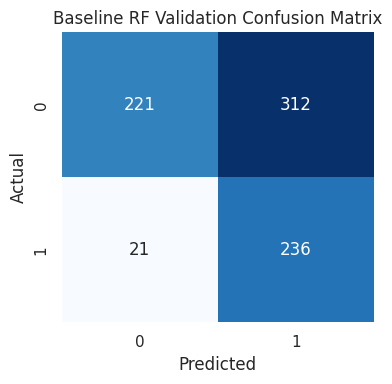

In [38]:
# Confusion matrix + importance
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Baseline RF Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



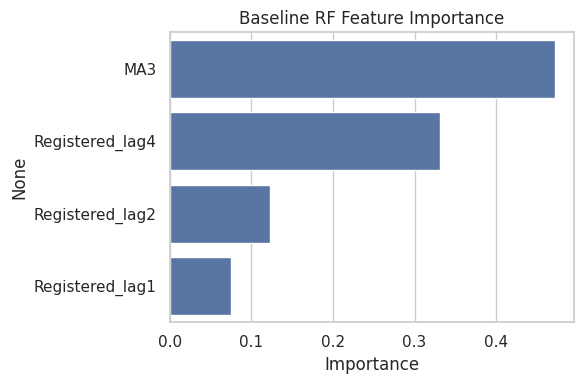

In [39]:
imp_base = pd.Series(rf_base.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=imp_base.values, y=imp_base.index)
plt.title("Baseline RF Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

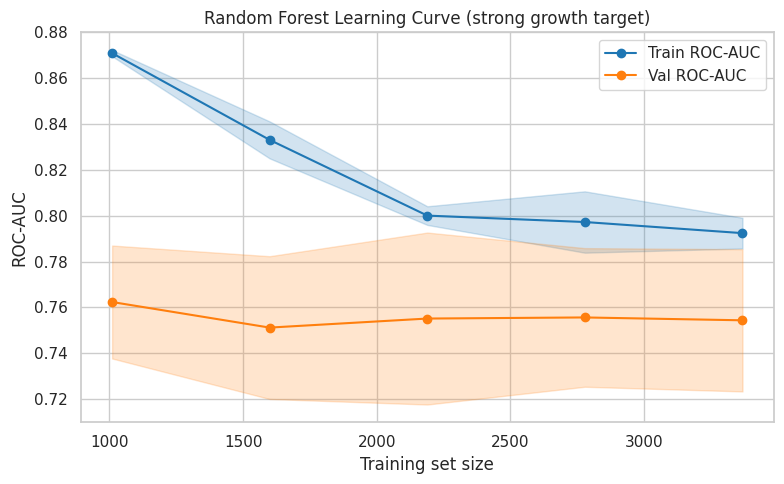

In [34]:
# 7) Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    rf_base,
    X, y,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.3, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="tab:blue", label="Train ROC-AUC")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color="tab:blue")
plt.plot(train_sizes, val_mean, "o-", color="tab:orange", label="Val ROC-AUC")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.2, color="tab:orange")
plt.title("Random Forest Learning Curve (strong growth target)")
plt.xlabel("Training set size")
plt.ylabel("ROC-AUC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# 8) Hyper-parameter tuning (small grid)
param_grid = {
    "n_estimators": [30, 60],
    "max_depth": [3, 4, 5],
    "min_samples_split": [4, 6],
    "min_samples_leaf": [3, 5],
    "max_features": ["sqrt"]
}

rf_tune = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

grid = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

rf_best = grid.best_estimator_

Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 60}
Best CV ROC-AUC: 0.8073518541607294


In [40]:
param_grid = {
    "n_estimators": [30, 60],
    "max_depth": [3, 4, 5],
    "min_samples_split": [4, 6],
    "min_samples_leaf": [3, 5],
    "max_features": ["sqrt"]
}

rf_tune = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

grid = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
rf_best = grid.best_estimator_


In [36]:
# 9) Tuned model – validation & test
y_val_pred_t = rf_best.predict(X_val)
y_val_proba_t = rf_best.predict_proba(X_val)[:, 1]

print("\n=== Tuned RF – Validation ===")
print(classification_report(y_val, y_val_pred_t, digits=3))
print("ROC-AUC (val):", roc_auc_score(y_val, y_val_proba_t))
print("Log loss (val):", log_loss(y_val, y_val_proba_t))

y_test_pred_t = rf_best.predict(X_test)
y_test_proba_t = rf_best.predict_proba(X_test)[:, 1]

print("\n=== Tuned RF – Test ===")
print(classification_report(y_test, y_test_pred_t, digits=3))
print("ROC-AUC (test):", roc_auc_score(y_test, y_test_proba_t))
print("Log loss (test):", log_loss(y_test, y_test_proba_t))


=== Tuned RF – Validation ===
              precision    recall  f1-score   support

           0      0.897     0.473     0.619       533
           1      0.448     0.887     0.595       257

    accuracy                          0.608       790
   macro avg      0.672     0.680     0.607       790
weighted avg      0.751     0.608     0.611       790

ROC-AUC (val): 0.7948292098904227
Log loss (val): 0.5822710300663574

=== Tuned RF – Test ===
              precision    recall  f1-score   support

           0      0.899     0.475     0.622       711
           1      0.449     0.889     0.597       342

    accuracy                          0.610      1053
   macro avg      0.674     0.682     0.609      1053
weighted avg      0.753     0.610     0.614      1053

ROC-AUC (test): 0.7803727556114854
Log loss (test): 0.5935719552562089


In [42]:
best_params = grid.best_params_
best_cv_auc = grid.best_score_

summary_tuning = pd.DataFrame({
    "Parameter": list(best_params.keys()) + ["CV_ROC_AUC"],
    "Value": list(best_params.values()) + [round(best_cv_auc, 3)]
})
summary_tuning


,Parameter,Value
0,max_depth,5
1,max_features,sqrt
2,min_samples_leaf,3
3,min_samples_split,4
4,n_estimators,60
5,CV_ROC_AUC,0.807


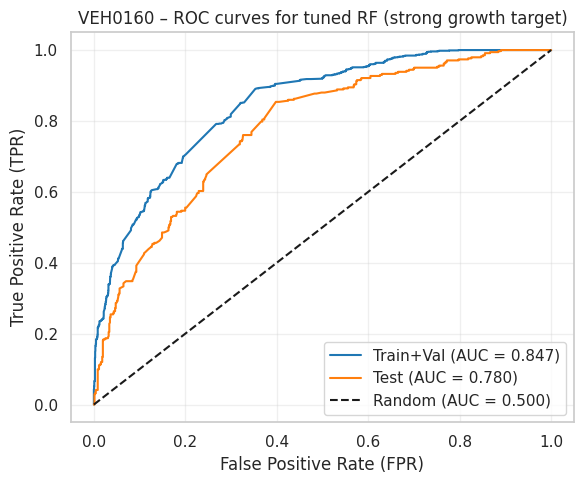

In [37]:
# 10) ROC curves train+val vs test
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

rf_best.fit(X_trainval, y_trainval)

y_trainval_proba = rf_best.predict_proba(X_trainval)[:, 1]
y_test_proba_final = rf_best.predict_proba(X_test)[:, 1]

fpr_tv, tpr_tv, _ = roc_curve(y_trainval, y_trainval_proba)
auc_tv = auc(fpr_tv, tpr_tv)
fpr_te, tpr_te, _ = roc_curve(y_test, y_test_proba_final)
auc_te = auc(fpr_te, tpr_te)

plt.figure(figsize=(6, 5))
plt.plot(fpr_tv, tpr_tv, label=f"Train+Val (AUC = {auc_tv:.3f})", color="tab:blue")
plt.plot(fpr_te, tpr_te, label=f"Test (AUC = {auc_te:.3f})", color="tab:orange")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("VEH0160 – ROC curves for tuned RF (strong growth target)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
